# Проект 2. Разведывательный анализ данных

#### Целью данного проекта является проведение анализа данных (EDA). Суть проекта - отследить влияние условий жизни учащихся в возрасте от 15 до 22 лет на их успеваемость по математике, чтобы на ранней стадии выявлять студентов, находящихся в группе риска. Для этого были поставлены следующие задачи:

1) Провести первичный анализ данных

2) Выполнить корреляционный анализ количественных показателей

3) Проанализировать номинативные переменные

4) Сделать выводы и сформировать таблицу данных для дальнейшей работы

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from statistics import mode
from scipy.stats import ttest_ind

%matplotlib inline


pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)

### Предобработка

In [2]:
# Функция для автоматического построения гистограммы, вывода статистичсеких
# показателей и подсчета значений (применима для количественных переменных)
def values_describe_hist(column):
    display(column.value_counts(dropna=False).reset_index())
    display(column.hist())
    display(column.describe())

# Фунция для замены отсутствующих значений на модальное (для качественных)


def fillna_mode(obj_column):
    mode_of_column = mode(obj_column)
    obj_column = obj_column.fillna(mode_of_column)
    return obj_column

# Фунция для замены отсутствующих значений на медианное (для количественных)


def fillna_median(num_column):
    median_of_column = num_column.median()
    num_column = num_column.fillna(median_of_column)
    return num_column

# Функция для построения box-plot


def get_boxplot(column):
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(data=students, x=column, y='score', ax=ax)
    ax.set_title('Boxplot for ' + column)
    plt.show()

# Функция для проведения теста Стьюдента


def get_stat_dif(column):
    cols = students.loc[:, column].value_counts().index[:10]
    combinations_all = list(combinations(cols, 2))
    for comb in combinations_all:
        if ttest_ind(students.loc[students.loc[:, column] == comb[0], 'score'],
                     students.loc[students.loc[:, column] == comb[1], 'score']).pvalue \
                <= 0.05/len(combinations_all):  # Учли поправку Бонферони
            print('Найдены статистически значимые различия для колонки', column)
            break

In [3]:
students = pd.read_csv('stud_math.xls')
display(students.head(5))
display(students.info())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,"studytime, granular",higher,internet,romantic,famrel,freetime,goout,health,absences,score
0,GP,F,18,U,NaN,A,4.0,4.0,at_home,teacher,course,mother,2.0,2.0,0.0,yes,no,no,no,yes,-6.0,yes,NaN,no,4.0,3.0,4.0,3.0,6.0,30.0
1,GP,F,17,U,GT3,NaN,1.0,1.0,at_home,other,course,father,1.0,2.0,0.0,no,yes,no,no,no,-6.0,yes,yes,no,5.0,3.0,3.0,3.0,4.0,30.0
2,GP,F,15,U,LE3,T,1.0,1.0,at_home,other,other,mother,1.0,2.0,3.0,yes,no,NaN,no,yes,-6.0,yes,yes,NaN,4.0,3.0,2.0,3.0,10.0,50.0
3,GP,F,15,U,GT3,T,4.0,2.0,health,NaN,home,mother,1.0,3.0,0.0,no,yes,yes,yes,yes,-9.0,yes,yes,yes,3.0,2.0,2.0,5.0,2.0,75.0
4,GP,F,16,U,GT3,T,3.0,3.0,other,other,home,father,1.0,2.0,0.0,no,yes,yes,no,yes,-6.0,yes,no,no,4.0,3.0,2.0,5.0,4.0,50.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   school               395 non-null    object 
 1   sex                  395 non-null    object 
 2   age                  395 non-null    int64  
 3   address              378 non-null    object 
 4   famsize              368 non-null    object 
 5   Pstatus              350 non-null    object 
 6   Medu                 392 non-null    float64
 7   Fedu                 371 non-null    float64
 8   Mjob                 376 non-null    object 
 9   Fjob                 359 non-null    object 
 10  reason               378 non-null    object 
 11  guardian             364 non-null    object 
 12  traveltime           367 non-null    float64
 13  studytime            388 non-null    float64
 14  failures             373 non-null    float64
 15  schoolsup            386 non-null    obj

None

In [4]:
students.columns = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
                    'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
                    'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
                    'studytime_granular', 'higher', 'internet', 'romantic', 'famrel',
                    'freetime', 'goout', 'health', 'absences', 'score']

# Первичный анализ данных

### School

In [5]:
students.school.value_counts(dropna=False).reset_index()

,index,school
0,GP,349
1,MS,46


### Sex

In [6]:
students.sex.value_counts(dropna=False).reset_index()

,index,sex
0,F,208
1,M,187


### Age

,index,age
0,16,104
1,17,98
2,18,82
3,15,82
4,19,24
5,20,3
6,22,1
7,21,1


count    395.000000
mean      16.696203
std        1.276043
min       15.000000
25%       16.000000
50%       17.000000
75%       18.000000
max       22.000000
Name: age, dtype: float64

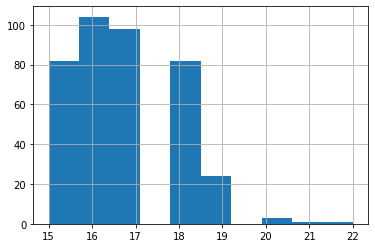

In [7]:
values_describe_hist(students.age)

##### На данной гистограмме видно, что большинство школьников 16-18 летнего возраста (25-ый квартиль = 16, 75-ый квартиль = 18)

### Address

In [8]:
display(students.address.value_counts(dropna=False).reset_index())

# После выполнения кода были выявлены пустые значения. В дальнейшем, пустые
# значения номинативных показателей будут заменены на моду, а значения
# количественных на медиану

students.address = fillna_mode(students.address)
students.address.value_counts(dropna=False).reset_index()

,index,address
0,U,295
1,R,83
2,NaN,17


,index,address
0,U,312
1,R,83


### Famsize

In [9]:
display(students.famsize.value_counts(dropna=False).reset_index())

students.famsize = fillna_mode(students.famsize)
students.famsize.value_counts(dropna=False).reset_index()

,index,famsize
0,GT3,261
1,LE3,107
2,NaN,27


,index,famsize
0,GT3,288
1,LE3,107


### Pstatus

In [10]:
display(students.Pstatus.value_counts(dropna=False).reset_index())

students.Pstatus = fillna_mode(students.Pstatus)
students.Pstatus.value_counts(dropna=False).reset_index()

,index,Pstatus
0,T,314
1,NaN,45
2,A,36


,index,Pstatus
0,T,359
1,A,36


### Medu

,index,Medu
0,4.0,131
1,2.0,102
2,3.0,97
3,1.0,59
4,0.0,3
5,NaN,3


,index,Medu
0,4.0,131
1,2.0,102
2,3.0,100
3,1.0,59
4,0.0,3


count    395.000000
mean       2.751899
std        1.094154
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        4.000000
Name: Medu, dtype: float64

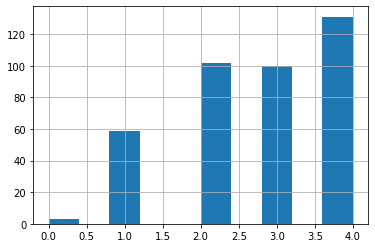

In [11]:
display(students.Medu.value_counts(dropna=False).reset_index())

# заменим пустые значения на медианное
students.Medu = fillna_median(students.Medu)
values_describe_hist(students.Medu)

### Fedu

,index,Fedu
0,2.0,106
1,3.0,96
2,4.0,88
3,1.0,78
4,NaN,24
5,0.0,2
6,40.0,1


count    371.000000
mean       2.614555
std        2.228732
min        0.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       40.000000
Name: Fedu, dtype: float64

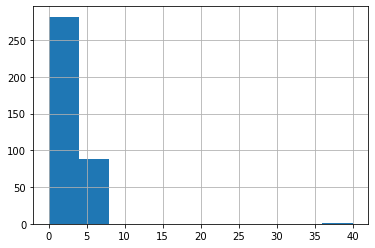

In [12]:
values_describe_hist(students.Fedu)

##### На гистограмме наблюдается выброс равный 40, так как по условию данная величина изменяется от 0 до 4. Можно предположить, что при заполнении данной графы была допущена ошибка. Уместно будет заменить 40 на 4.0

In [13]:
students.Fedu = fillna_median(students.Fedu)
students.Fedu = students.Fedu.replace(40, 4.0)

,index,Fedu
0,2.0,130
1,3.0,96
2,4.0,89
3,1.0,78
4,0.0,2


count    395.000000
mean       2.486076
std        1.062362
min        0.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: Fedu, dtype: float64

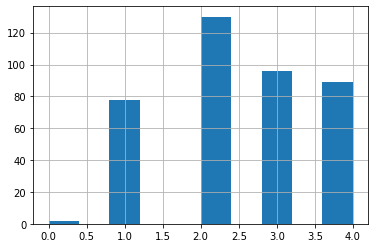

In [14]:
# Проверим
values_describe_hist(students.Fedu)

##### На вновь построенной диаграмме видно, что выброс был скорректирован

### Mjob

In [15]:
display(students.Mjob.value_counts(dropna=False).reset_index())

students.Mjob = fillna_mode(students.Mjob)
students.Mjob.value_counts(dropna=False).reset_index()

,index,Mjob
0,other,133
1,services,98
2,at_home,58
3,teacher,55
4,health,32
5,NaN,19


,index,Mjob
0,other,152
1,services,98
2,at_home,58
3,teacher,55
4,health,32


### Fjob

In [16]:
display(students.Fjob.value_counts(dropna=False).reset_index())

students.Fjob = fillna_mode(students.Fjob)
students.Fjob.value_counts(dropna=False).reset_index()

,index,Fjob
0,other,197
1,services,102
2,NaN,36
3,teacher,29
4,at_home,16
5,health,15


,index,Fjob
0,other,233
1,services,102
2,teacher,29
3,at_home,16
4,health,15


### Reason

In [17]:
display(students.reason.value_counts(dropna=False).reset_index())

students.reason = fillna_mode(students.reason)
students.reason.value_counts(dropna=False).reset_index()

,index,reason
0,course,137
1,home,104
2,reputation,103
3,other,34
4,NaN,17


,index,reason
0,course,154
1,home,104
2,reputation,103
3,other,34


### Guardian

In [18]:
display(students.guardian.value_counts(dropna=False).reset_index())

students.guardian = fillna_mode(students.guardian)
students.guardian.value_counts(dropna=False).reset_index()

,index,guardian
0,mother,250
1,father,86
2,NaN,31
3,other,28


,index,guardian
0,mother,281
1,father,86
2,other,28


### Traveltime

,index,traveltime
0,1.0,242
1,2.0,96
2,NaN,28
3,3.0,22
4,4.0,7


,index,traveltime
0,1.0,270
1,2.0,96
2,3.0,22
3,4.0,7


count    395.000000
mean       1.407595
std        0.678490
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        4.000000
Name: traveltime, dtype: float64

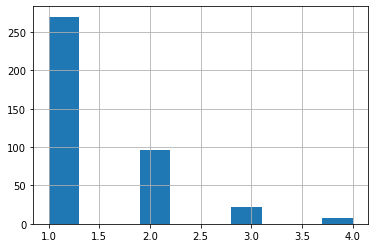

In [19]:
display(students.traveltime.value_counts(dropna=False).reset_index())

students.traveltime = fillna_median(students.traveltime)
values_describe_hist(students.traveltime)

##### Анализируя данную гистограмму, можно сделать вывод, что наибольшая часть школьников живет достаточно близко от своей школы. (1 - <15 мин., 2 - 15-30 мин., 3 - 30-60 мин., 4 - >60 мин.)

### Studytime

,index,studytime
0,2.0,194
1,1.0,103
2,3.0,64
3,4.0,27
4,NaN,7


,index,studytime
0,2.0,201
1,1.0,103
2,3.0,64
3,4.0,27


count    395.000000
mean       2.037975
std        0.834580
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: studytime, dtype: float64

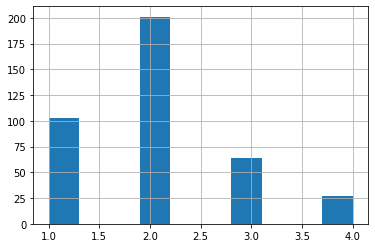

In [20]:
display(students.studytime.value_counts(dropna=False).reset_index())

students.studytime = fillna_median(students.studytime)
values_describe_hist(students.studytime)

##### На гистограмме распределения параметра "время на учебу после школы" видно, что большинсвто школьников тратят на домашнюю работу от 1 до 2, где  (1 - <2 часов, 2 - 2-5 часов, 3 - 5-10 часов, 4 - >10 часов)

### Failures

,index,failures
0,0.0,293
1,1.0,49
2,NaN,22
3,2.0,16
4,3.0,15


,index,failures
0,0.0,315
1,1.0,49
2,2.0,16
3,3.0,15


count    395.000000
mean       0.318987
std        0.726244
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        3.000000
Name: failures, dtype: float64

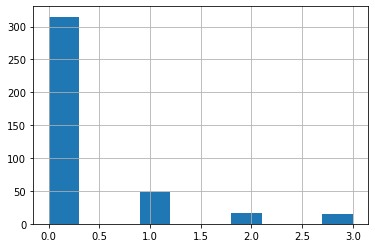

In [21]:
display(students.failures.value_counts(dropna=False).reset_index())

students.failures = fillna_median(students.failures)
values_describe_hist(students.failures)

##### Данный показатель говорит о том, что у наибольшинства школьников количество внеучебных неудач равняется нулю. (25-ый квартиль, как и 75-ый равны 0)

### Schoolsup

In [22]:
display(students.schoolsup.value_counts(dropna=False).reset_index())

students.schoolsup = fillna_mode(students.schoolsup)
students.schoolsup.value_counts(dropna=False).reset_index()

,index,schoolsup
0,no,335
1,yes,51
2,NaN,9


,index,schoolsup
0,no,344
1,yes,51


### Famsup

In [23]:
display(students.famsup.value_counts(dropna=False).reset_index())

students.famsup = fillna_mode(students.famsup)
students.famsup.value_counts(dropna=False).reset_index()

,index,famsup
0,yes,219
1,no,137
2,NaN,39


,index,famsup
0,yes,258
1,no,137


### Paid

In [24]:
display(students.paid.value_counts(dropna=False).reset_index())

students.paid = fillna_mode(students.paid)
students.paid.value_counts(dropna=False).reset_index()

,index,paid
0,no,200
1,yes,155
2,NaN,40


,index,paid
0,no,240
1,yes,155


### Activities

In [25]:
display(students.activities.value_counts(dropna=False).reset_index())

students.activities = fillna_mode(students.activities)
students.activities.value_counts(dropna=False).reset_index()

,index,activities
0,yes,195
1,no,186
2,NaN,14


,index,activities
0,yes,209
1,no,186


### Nursery

In [26]:
display(students.nursery.value_counts(dropna=False).reset_index())

students.nursery = fillna_mode(students.nursery)
students.nursery.value_counts(dropna=False).reset_index()

,index,nursery
0,yes,300
1,no,79
2,NaN,16


,index,nursery
0,yes,316
1,no,79


### Higher

In [27]:
display(students.higher.value_counts(dropna=False).reset_index())

students.higher = fillna_mode(students.higher)
students.higher.value_counts(dropna=False).reset_index()

,index,higher
0,yes,356
1,NaN,20
2,no,19


,index,higher
0,yes,376
1,no,19


### Internet

In [28]:
display(students.internet.value_counts(dropna=False).reset_index())

students.internet = fillna_mode(students.internet)
students.internet.value_counts(dropna=False).reset_index()

,index,internet
0,yes,305
1,no,56
2,NaN,34


,index,internet
0,yes,339
1,no,56


### Romantic

In [29]:
display(students.romantic.value_counts(dropna=False).reset_index())

students.romantic = fillna_mode(students.romantic)
students.romantic.value_counts(dropna=False).reset_index()

,index,romantic
0,no,240
1,yes,124
2,NaN,31


,index,romantic
0,no,271
1,yes,124


### Famrel

,index,famrel
0,4.0,182
1,5.0,99
2,3.0,62
3,NaN,27
4,2.0,17
5,1.0,7
6,-1.0,1


count    368.000000
mean       3.937500
std        0.927277
min       -1.000000
25%        4.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: famrel, dtype: float64

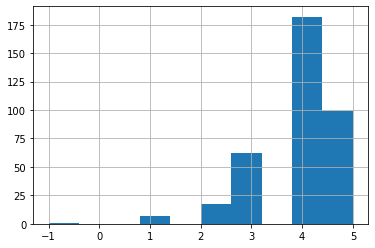

In [30]:
values_describe_hist(students.famrel)

##### В колонке присутствует единственный выброс равный -1. Данный показатель имеет следующее изменение: от 1 - очень плохо до 5 - очень хорошо. Можно предположить, что школьник допустил ошибку при заполнении данных, или же он намеренно поставил -1, чтобы показать ужасные отношения с родителями, однако это все равно относится к 1.

In [31]:
students.famrel = fillna_median(students.famrel)
students.famrel = students.famrel.replace(-1, 1)

,index,famrel
0,4.0,209
1,5.0,99
2,3.0,62
3,2.0,17
4,1.0,8


count    395.000000
mean       3.946835
std        0.872425
min        1.000000
25%        4.000000
50%        4.000000
75%        4.500000
max        5.000000
Name: famrel, dtype: float64

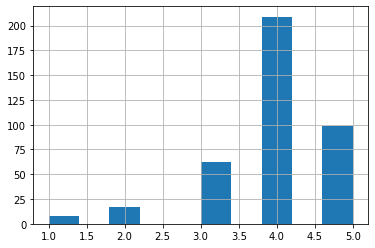

In [32]:
# Убедимся, что выброс был скорректирован и пустые значения заменены
values_describe_hist(students.famrel)

##### На данной гистограмме видно, что большинство школьников оценивает свои семейные отношения как хорошие и очень хорошие (25-ый квартиль 4, 75-ый квартиль 5)

### Freetime

,index,freetime
0,3.0,153
1,4.0,112
2,2.0,63
3,5.0,38
4,1.0,18
5,NaN,11


,index,freetime
0,3.0,164
1,4.0,112
2,2.0,63
3,5.0,38
4,1.0,18


count    395.000000
mean       3.225316
std        0.980711
min        1.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: freetime, dtype: float64

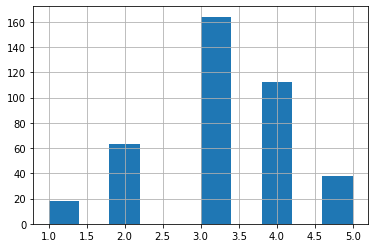

In [33]:
display(students.freetime.value_counts(dropna=False).reset_index())

students.freetime = fillna_median(students.freetime)
values_describe_hist(students.freetime)

##### На данной гистограмме видно, что медианной значение составляет 3, 25-ый квартиль 3, а 75-ый 4 (где от 1 - очень мало до 5 - очень много). Это значит, что у школьников остается среднее количество свободного времени после школы с перевесом в большую сторону

### Goout

,index,goout
0,3.0,127
1,2.0,101
2,4.0,84
3,5.0,52
4,1.0,23
5,NaN,8


,index,goout
0,3.0,135
1,2.0,101
2,4.0,84
3,5.0,52
4,1.0,23


count    395.000000
mean       3.103797
std        1.104610
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: goout, dtype: float64

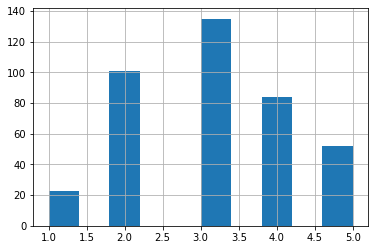

In [34]:
display(students.goout.value_counts(dropna=False).reset_index())

students.goout = fillna_median(students.goout)
values_describe_hist(students.goout)

##### Данное распределение можно условно назвать нормальным. С медианным значением равным 3. Это значит, что большинство школьников, как и в предыдущем показателе, проводят с друзьями среднее количество времени

### Health

,index,health
0,5.0,138
1,3.0,89
2,4.0,63
3,1.0,47
4,2.0,43
5,NaN,15


,index,health
0,5.0,138
1,3.0,89
2,4.0,78
3,1.0,47
4,2.0,43


count    395.000000
mean       3.549367
std        1.372118
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: health, dtype: float64

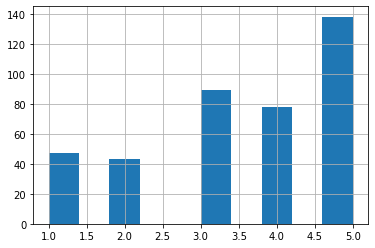

In [35]:
display(students.health.value_counts(dropna=False).reset_index())

students.health = fillna_median(students.health)
values_describe_hist(students.health)

##### Состояние здоровья школьников, в большинстве своем (25-ый квартиль 3, 75-ый квартиль 5), оценивается позитивно (где, от 1 - очень плохо до 5 - очень хорошо)

### Absences

,index,absences
0,0.0,111
1,2.0,60
2,4.0,53
3,6.0,31
4,8.0,21
5,10.0,17
6,12.0,12
7,NaN,12
8,14.0,12
9,3.0,8


,index,absences
0,0.0,111
1,4.0,65
2,2.0,60
3,6.0,31
4,8.0,21
5,10.0,17
6,12.0,12
7,14.0,12
8,3.0,8
9,16.0,7


count    395.000000
mean       7.179747
std       23.111967
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max      385.000000
Name: absences, dtype: float64

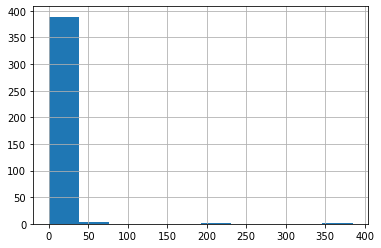

In [36]:
display(students.absences.value_counts(dropna=False).reset_index().head(10))

students.absences = fillna_median(students.absences)
values_describe_hist(students.absences)

##### На данной гистограмме распределения пропущенных занятий видно, что почти все школьники пропустили мало занятий( межквартильный размах измеряется от 4 до 8), учитывая, что максимальное значение равняется 385.

### Score

,index,score
0,50.0,54
1,55.0,46
2,0.0,37
3,75.0,33
4,65.0,31
5,40.0,31
6,60.0,31
7,45.0,27
8,70.0,27
9,80.0,16


,index,score
0,50.0,54
1,55.0,52
2,0.0,37
3,75.0,33
4,65.0,31
5,40.0,31
6,60.0,31
7,70.0,27
8,45.0,27
9,80.0,16


count    395.000000
mean      52.303797
std       22.746314
min        0.000000
25%       40.000000
50%       55.000000
75%       70.000000
max      100.000000
Name: score, dtype: float64

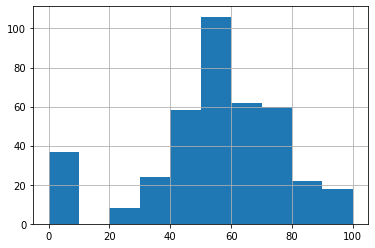

In [37]:
display(students.score.value_counts(dropna=False).reset_index().head(10))

students.score = fillna_median(students.score)
values_describe_hist(students.score)

##### На гистограмме распределения баллов по госэкзамену стоит обратить внимание на колонку со значениями 0. Можно предположить, что в нее входят не только люди, которые завалили экзамен, но и те кто на него не пришел или был не допущен. Так как уточнений нет, то предлагается оставить колонку без изменений.

### ***Studytime_granular

,index,studytime_granular
0,-6.0,194
1,-3.0,103
2,-9.0,64
3,-12.0,27
4,NaN,7


,index,studytime_granular
0,-6.0,201
1,-3.0,103
2,-9.0,64
3,-12.0,27


count    395.000000
mean      -6.113924
std        2.503740
min      -12.000000
25%       -6.000000
50%       -6.000000
75%       -3.000000
max       -3.000000
Name: studytime_granular, dtype: float64

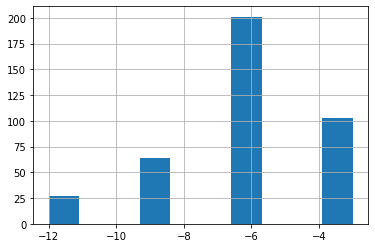

In [38]:
display(students.studytime_granular.value_counts(dropna=False).reset_index())

students.studytime_granular = fillna_median(students.studytime_granular)
values_describe_hist(students.studytime_granular)

##### По результатам первичного анализа данных были заменены пустные значения на медианные (для количественных) и на модальные (для качественных переменных). Также были устранены выбросы. 

# Корреляционный анализ

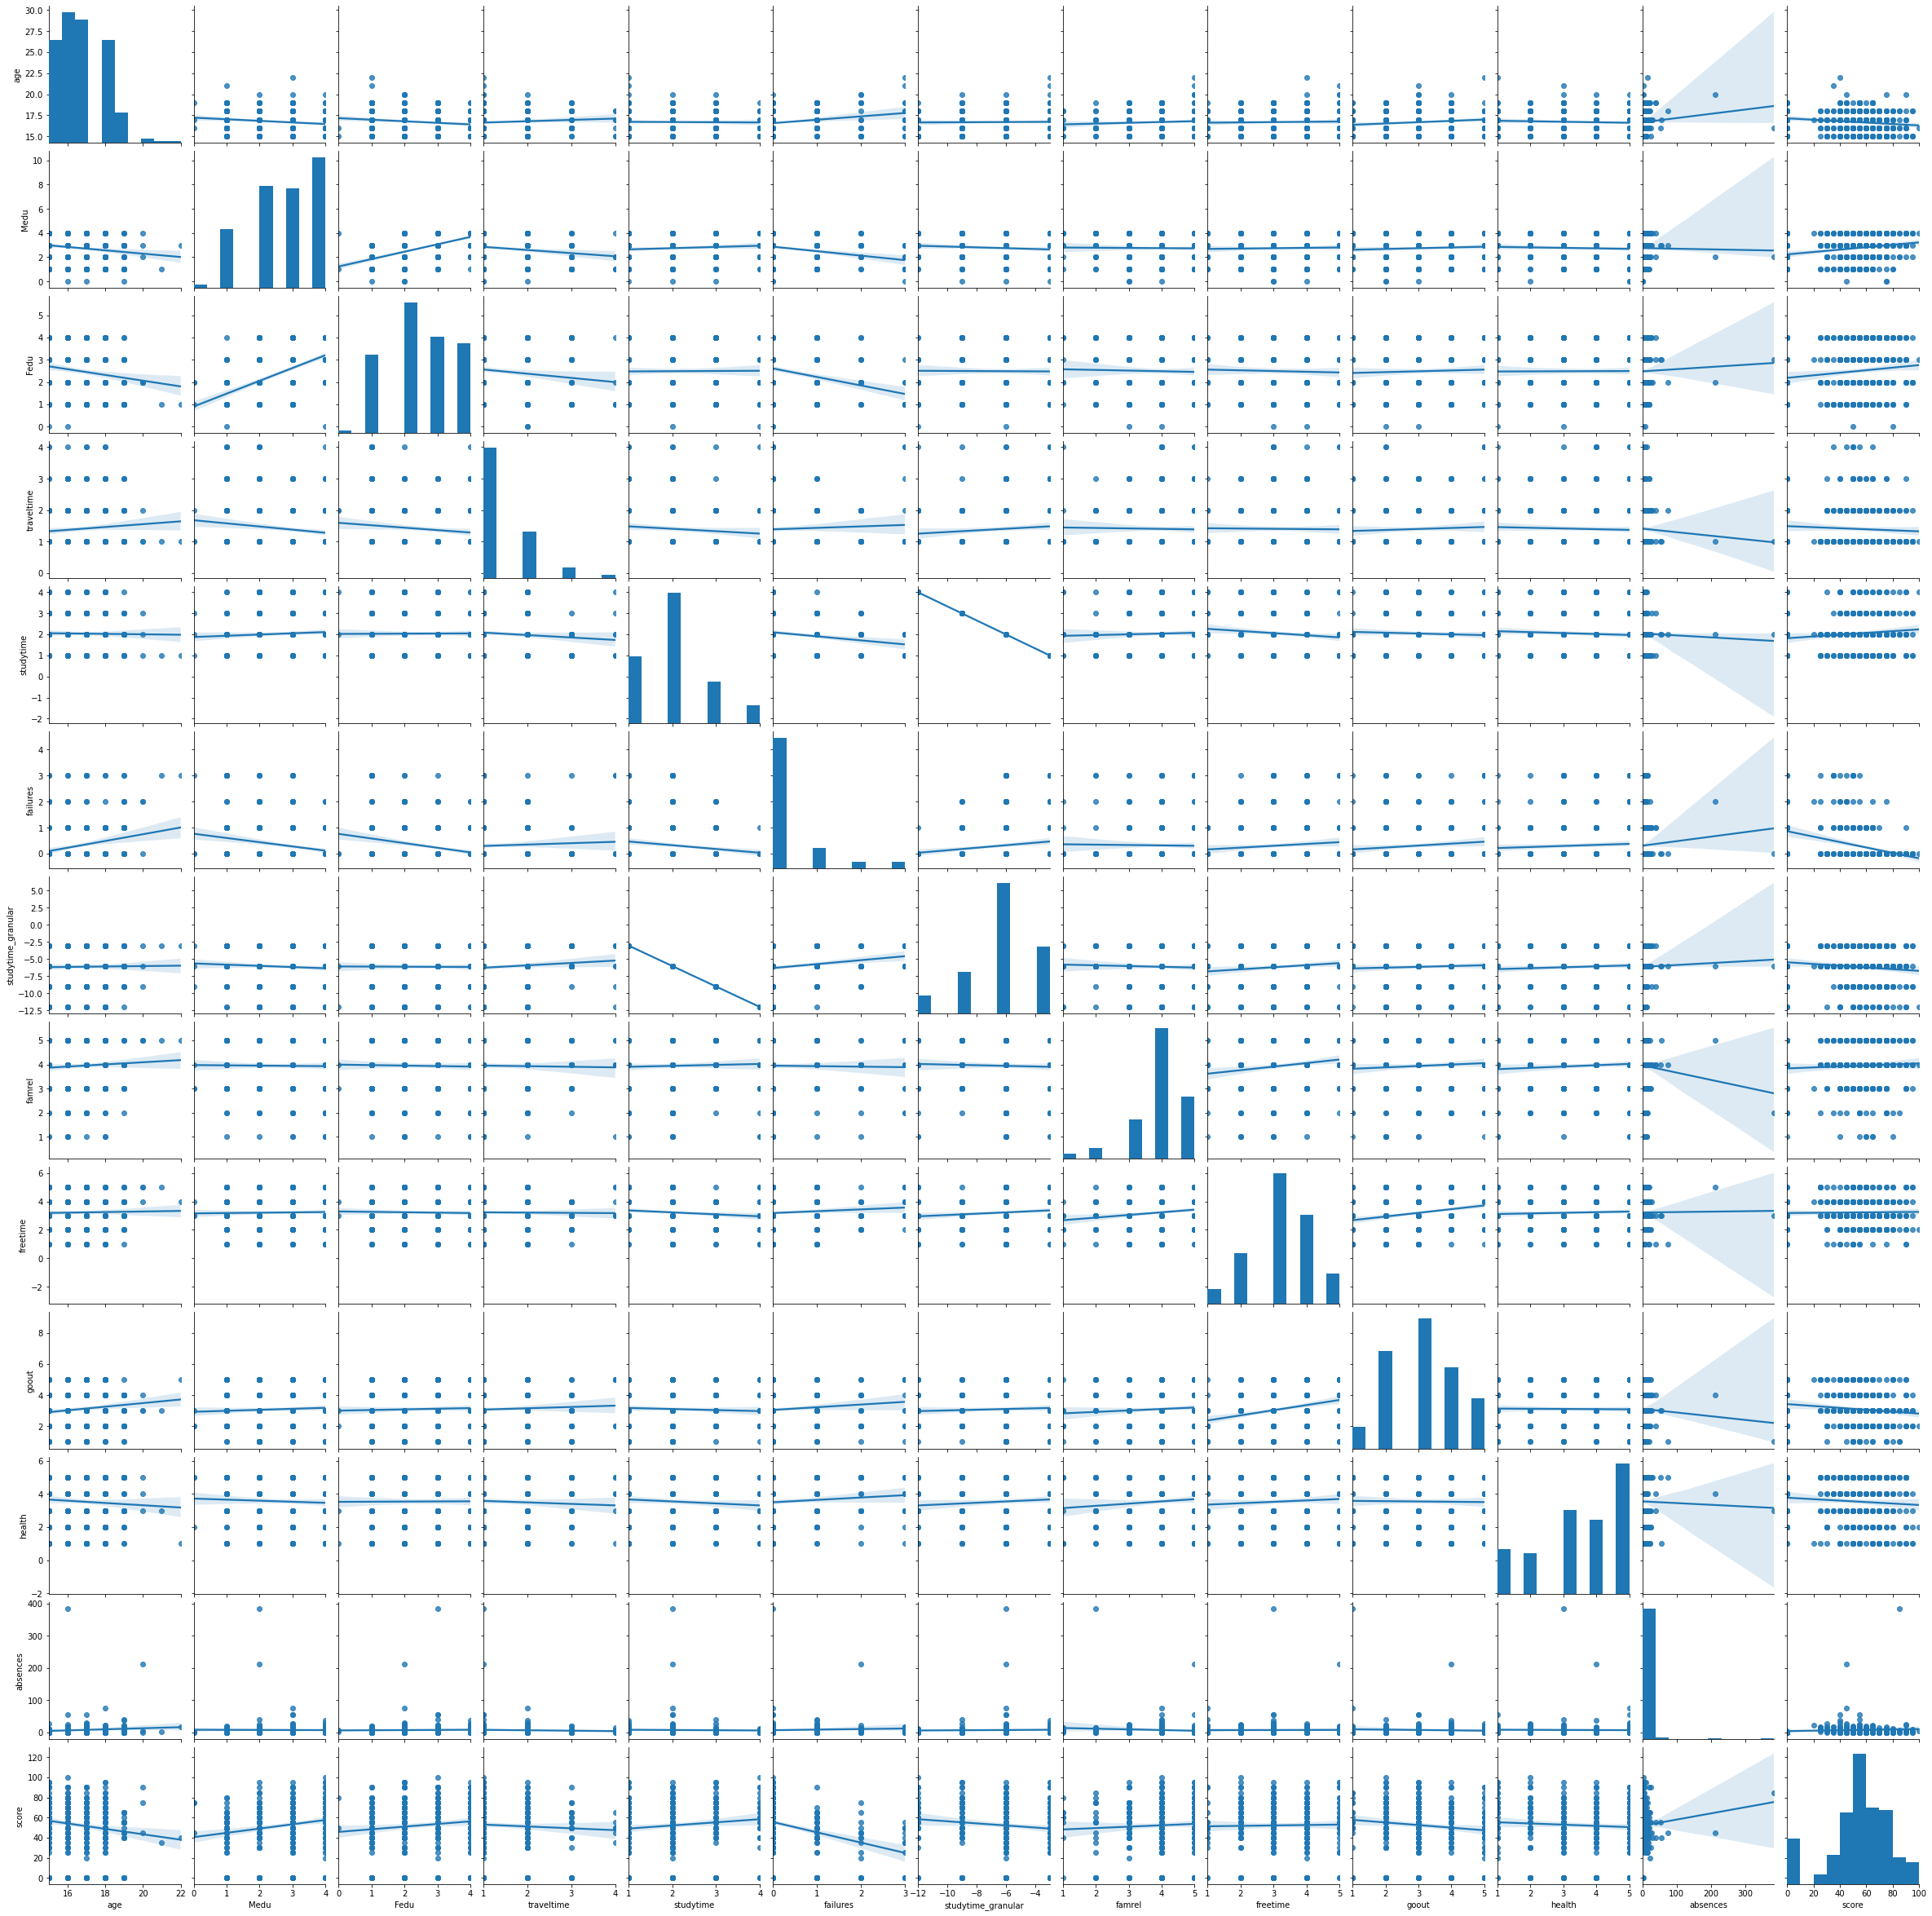

In [39]:
sns.pairplot(students, kind='reg')

,age,Medu,Fedu,traveltime,studytime,failures,studytime_granular,famrel,freetime,goout,health,absences,score
age,1.000000,-0.161375,-0.154781,0.084755,-0.015355,0.228081,0.015355,0.065250,0.026443,0.134069,-0.063892,0.091531,-0.151150
Medu,-0.161375,1.000000,0.593116,-0.160877,0.077050,-0.245110,-0.077050,-0.013853,0.026210,0.063361,-0.050991,-0.010979,0.205568
Fedu,-0.154781,0.593116,1.000000,-0.120629,0.007754,-0.260690,-0.007754,-0.024077,-0.029868,0.039084,0.006132,0.021345,0.122642
traveltime,0.084755,-0.160877,-0.120629,1.000000,-0.094637,0.049670,0.094637,-0.019040,-0.012496,0.051775,-0.044842,-0.038511,-0.055243
studytime,-0.015355,0.077050,0.007754,-0.094637,1.000000,-0.166598,-1.000000,0.037638,-0.119014,-0.051090,-0.073674,-0.025619,0.114371
failures,0.228081,-0.245110,-0.260690,0.049670,-0.166598,1.000000,0.166598,-0.017230,0.094826,0.113649,0.075849,0.055245,-0.326532
studytime_granular,0.015355,-0.077050,-0.007754,0.094637,-1.000000,0.166598,1.000000,-0.037638,0.119014,0.051090,0.073674,0.025619,-0.114371
famrel,0.065250,-0.013853,-0.024077,-0.019040,0.037638,-0.017230,-0.037638,1.000000,0.165324,0.074217,0.085947,-0.079959,0.053510
freetime,0.026443,0.026210,-0.029868,-0.012496,-0.119014,0.094826,0.119014,0.165324,1.000000,0.292305,0.060557,0.006943,0.018200
goout,0.134069,0.063361,0.039084,0.051775,-0.051090,0.113649,0.051090,0.074217,0.292305,1.000000,-0.014274,-0.049745,-0.125708


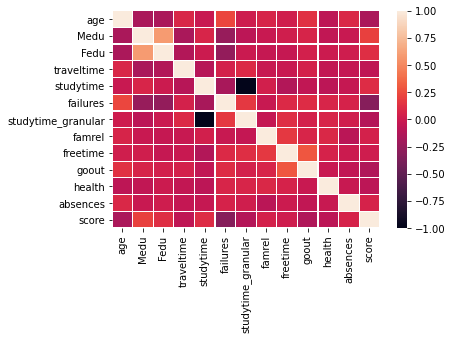

In [40]:
display(students.corr())
sns.heatmap(students.corr(), linewidth=0.2)

##### После построения тепловой карты видно, что:
1) значение коэффициента корреляции studytime_granular и studytime характеризуется очень сильной связью (-1). Уберем studytime_granular;

2) коэффициент корреляции показателей Medu и Fedu равен 0.59, что соответстует средней корреляции. Возможно, один из показателей можно будет убрать.

# Анализ номинативных переменных

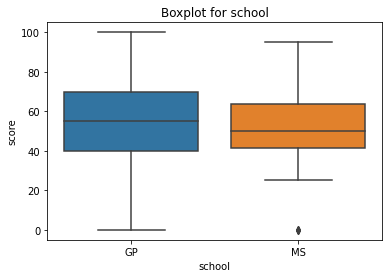

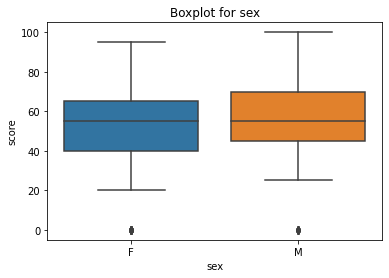

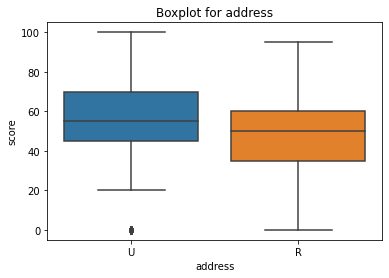

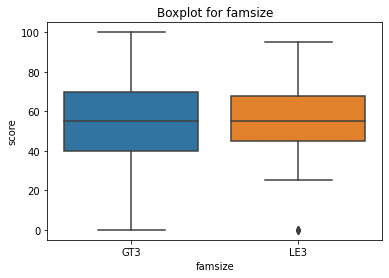

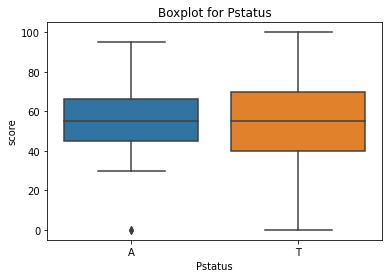

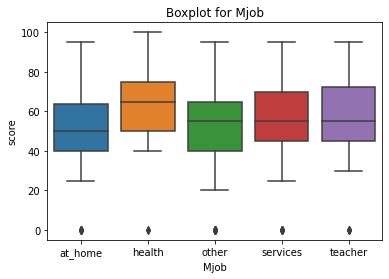

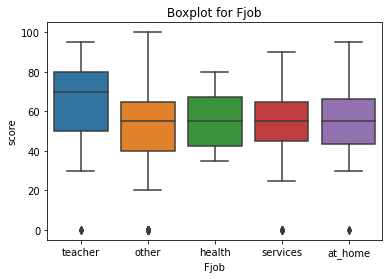

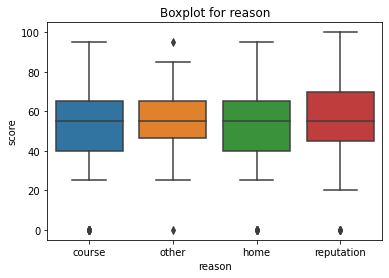

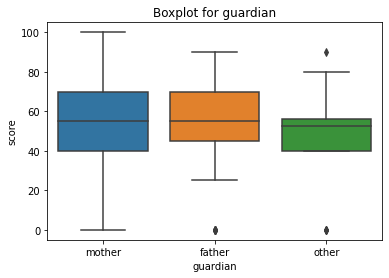

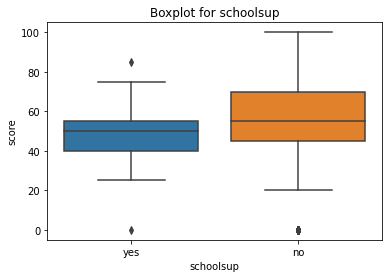

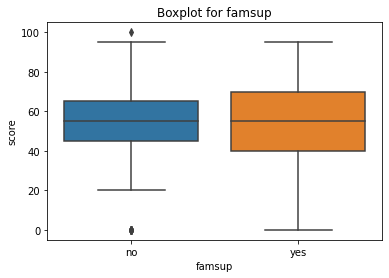

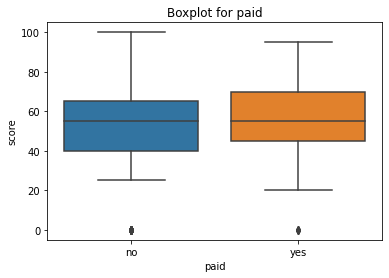

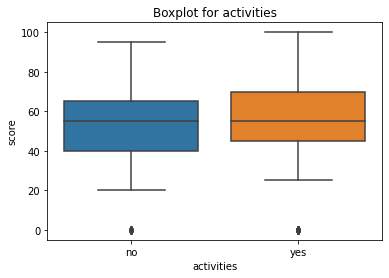

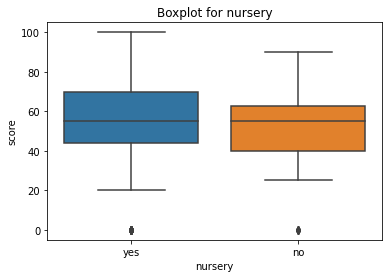

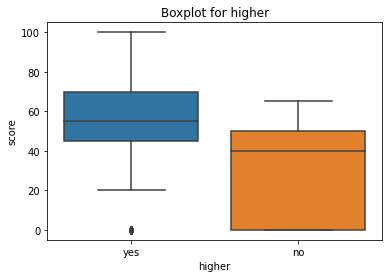

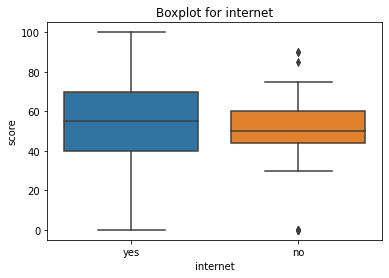

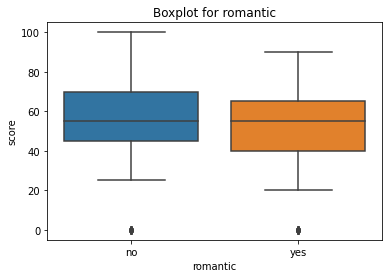

In [41]:
for col in ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
            'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
            'nursery', 'higher', 'internet', 'romantic']:
    get_boxplot(col)

##### Построенные boxplot показали, что не все номинативные сильно влияют на результаты гос экзамена. Проверим это с помощью статистики, а именно теста Стьюдента:

In [42]:
for col in ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
            'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
            'nursery', 'higher', 'internet', 'romantic']:
    get_stat_dif(col)

Найдены статистически значимые различия для колонки address
Найдены статистически значимые различия для колонки Mjob
Найдены статистически значимые различия для колонки higher
Найдены статистически значимые различия для колонки romantic


##### Исходя из теста Стьюдента видим, что значимыми величинами являются address, Mjob, higher, romantic

# Таблица для модели

In [43]:
students_for_model = students.loc[:, ['age', 'address', 'Medu', 'Fedu', 'Mjob',
                                      'traveltime', 'studytime', 'failures', 'higher',
                                      'romantic', 'famrel', 'freetime', 'goout',
                                      'health', 'absences', 'score']]
students_for_model

,age,address,Medu,Fedu,Mjob,traveltime,studytime,failures,higher,romantic,famrel,freetime,goout,health,absences,score
0,18,U,4.0,4.0,at_home,2.0,2.0,0.0,yes,no,4.0,3.0,4.0,3.0,6.0,30.0
1,17,U,1.0,1.0,at_home,1.0,2.0,0.0,yes,no,5.0,3.0,3.0,3.0,4.0,30.0
2,15,U,1.0,1.0,at_home,1.0,2.0,3.0,yes,no,4.0,3.0,2.0,3.0,10.0,50.0
3,15,U,4.0,2.0,health,1.0,3.0,0.0,yes,yes,3.0,2.0,2.0,5.0,2.0,75.0
4,16,U,3.0,3.0,other,1.0,2.0,0.0,yes,no,4.0,3.0,2.0,5.0,4.0,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,U,2.0,2.0,services,1.0,2.0,2.0,yes,no,5.0,5.0,4.0,4.0,212.0,45.0
391,17,U,3.0,1.0,services,2.0,1.0,0.0,yes,no,2.0,4.0,5.0,2.0,3.0,80.0
392,21,R,1.0,1.0,other,1.0,1.0,3.0,yes,no,5.0,5.0,3.0,3.0,3.0,35.0
393,18,R,3.0,2.0,services,3.0,1.0,0.0,yes,no,4.0,4.0,1.0,5.0,0.0,50.0


# Итоги

### 1) В результате первичного анализа данных было выявлено, что данные являются достаточно "чистыми" с малым количеством  пропусков, которые были заполнены соответствующими значениями. Также были исправлены две колонки, в которых содеражлись выбросы.

### 2) По результатам корреляционного анализа и анализа номинативных переменных были выбраны значимые параметры, которые в дальнейшем можно использовать для построения модели.